In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_context("talk")
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle

from loren_frank_data_processing import (
    get_multiunit_dataframe,
    get_multiunit_dataframe2,
)

from src.parameters import ANIMALS

from Code4PaperFigs_EXP.utils import bandpassfilter, get_zero_phase, get_phase, compute_spike_array

### Load example data

In [2]:


epoch_key = ("bon", 8, 4)
animal, day, epoch = epoch_key
PreLoad_Data_DIR = (
    "/media/zilong/4TB Storage HDD/ReplayTrajectoryAnalysis/PreLoad-Data-old"
)
with open(
    os.path.join(PreLoad_Data_DIR, f"{animal}_{day:02d}_{epoch:02d}.pkl"), "rb"
) as f:
    data = pickle.load(f)

### plot decoded results

In [3]:
datafolder = (
    "/home/zilong/Desktop/AdaptiveAttractorForSequences/ExpData/ThetaSweepTrajectories"
)

animal, day, epoch = epoch_key
# load the classifier results
results = xr.open_dataset(
    os.path.join(
        datafolder,
        f"{animal}_{day:02d}_{epoch:02d}_cv_classifier_clusterless_results.nc",
    )
)

# get all time slice
t = data["position_info"].index / np.timedelta64(1, "s")

# load multiunit times
multiunit_times = [
    get_multiunit_dataframe(tetrode_key, ANIMALS)
    for tetrode_key in data["tetrode_info"].index
]
if multiunit_times[0] is None:
    multiunit_times = [
        get_multiunit_dataframe2(tetrode_key, ANIMALS)
        for tetrode_key in data["tetrode_info"].index
    ]
# reset index in multiunit_times to seconds and replace the original multiunit_times
for i in range(len(multiunit_times)):
    indext_i = multiunit_times[i].index / np.timedelta64(1, "s")
    multiunit_times[i].index = indext_i
    
pc_spike = data['spikes']['bon_08_04_017_001']    
    
time_slice = slice(t.min() + 243.5, t.min() + 246.5)

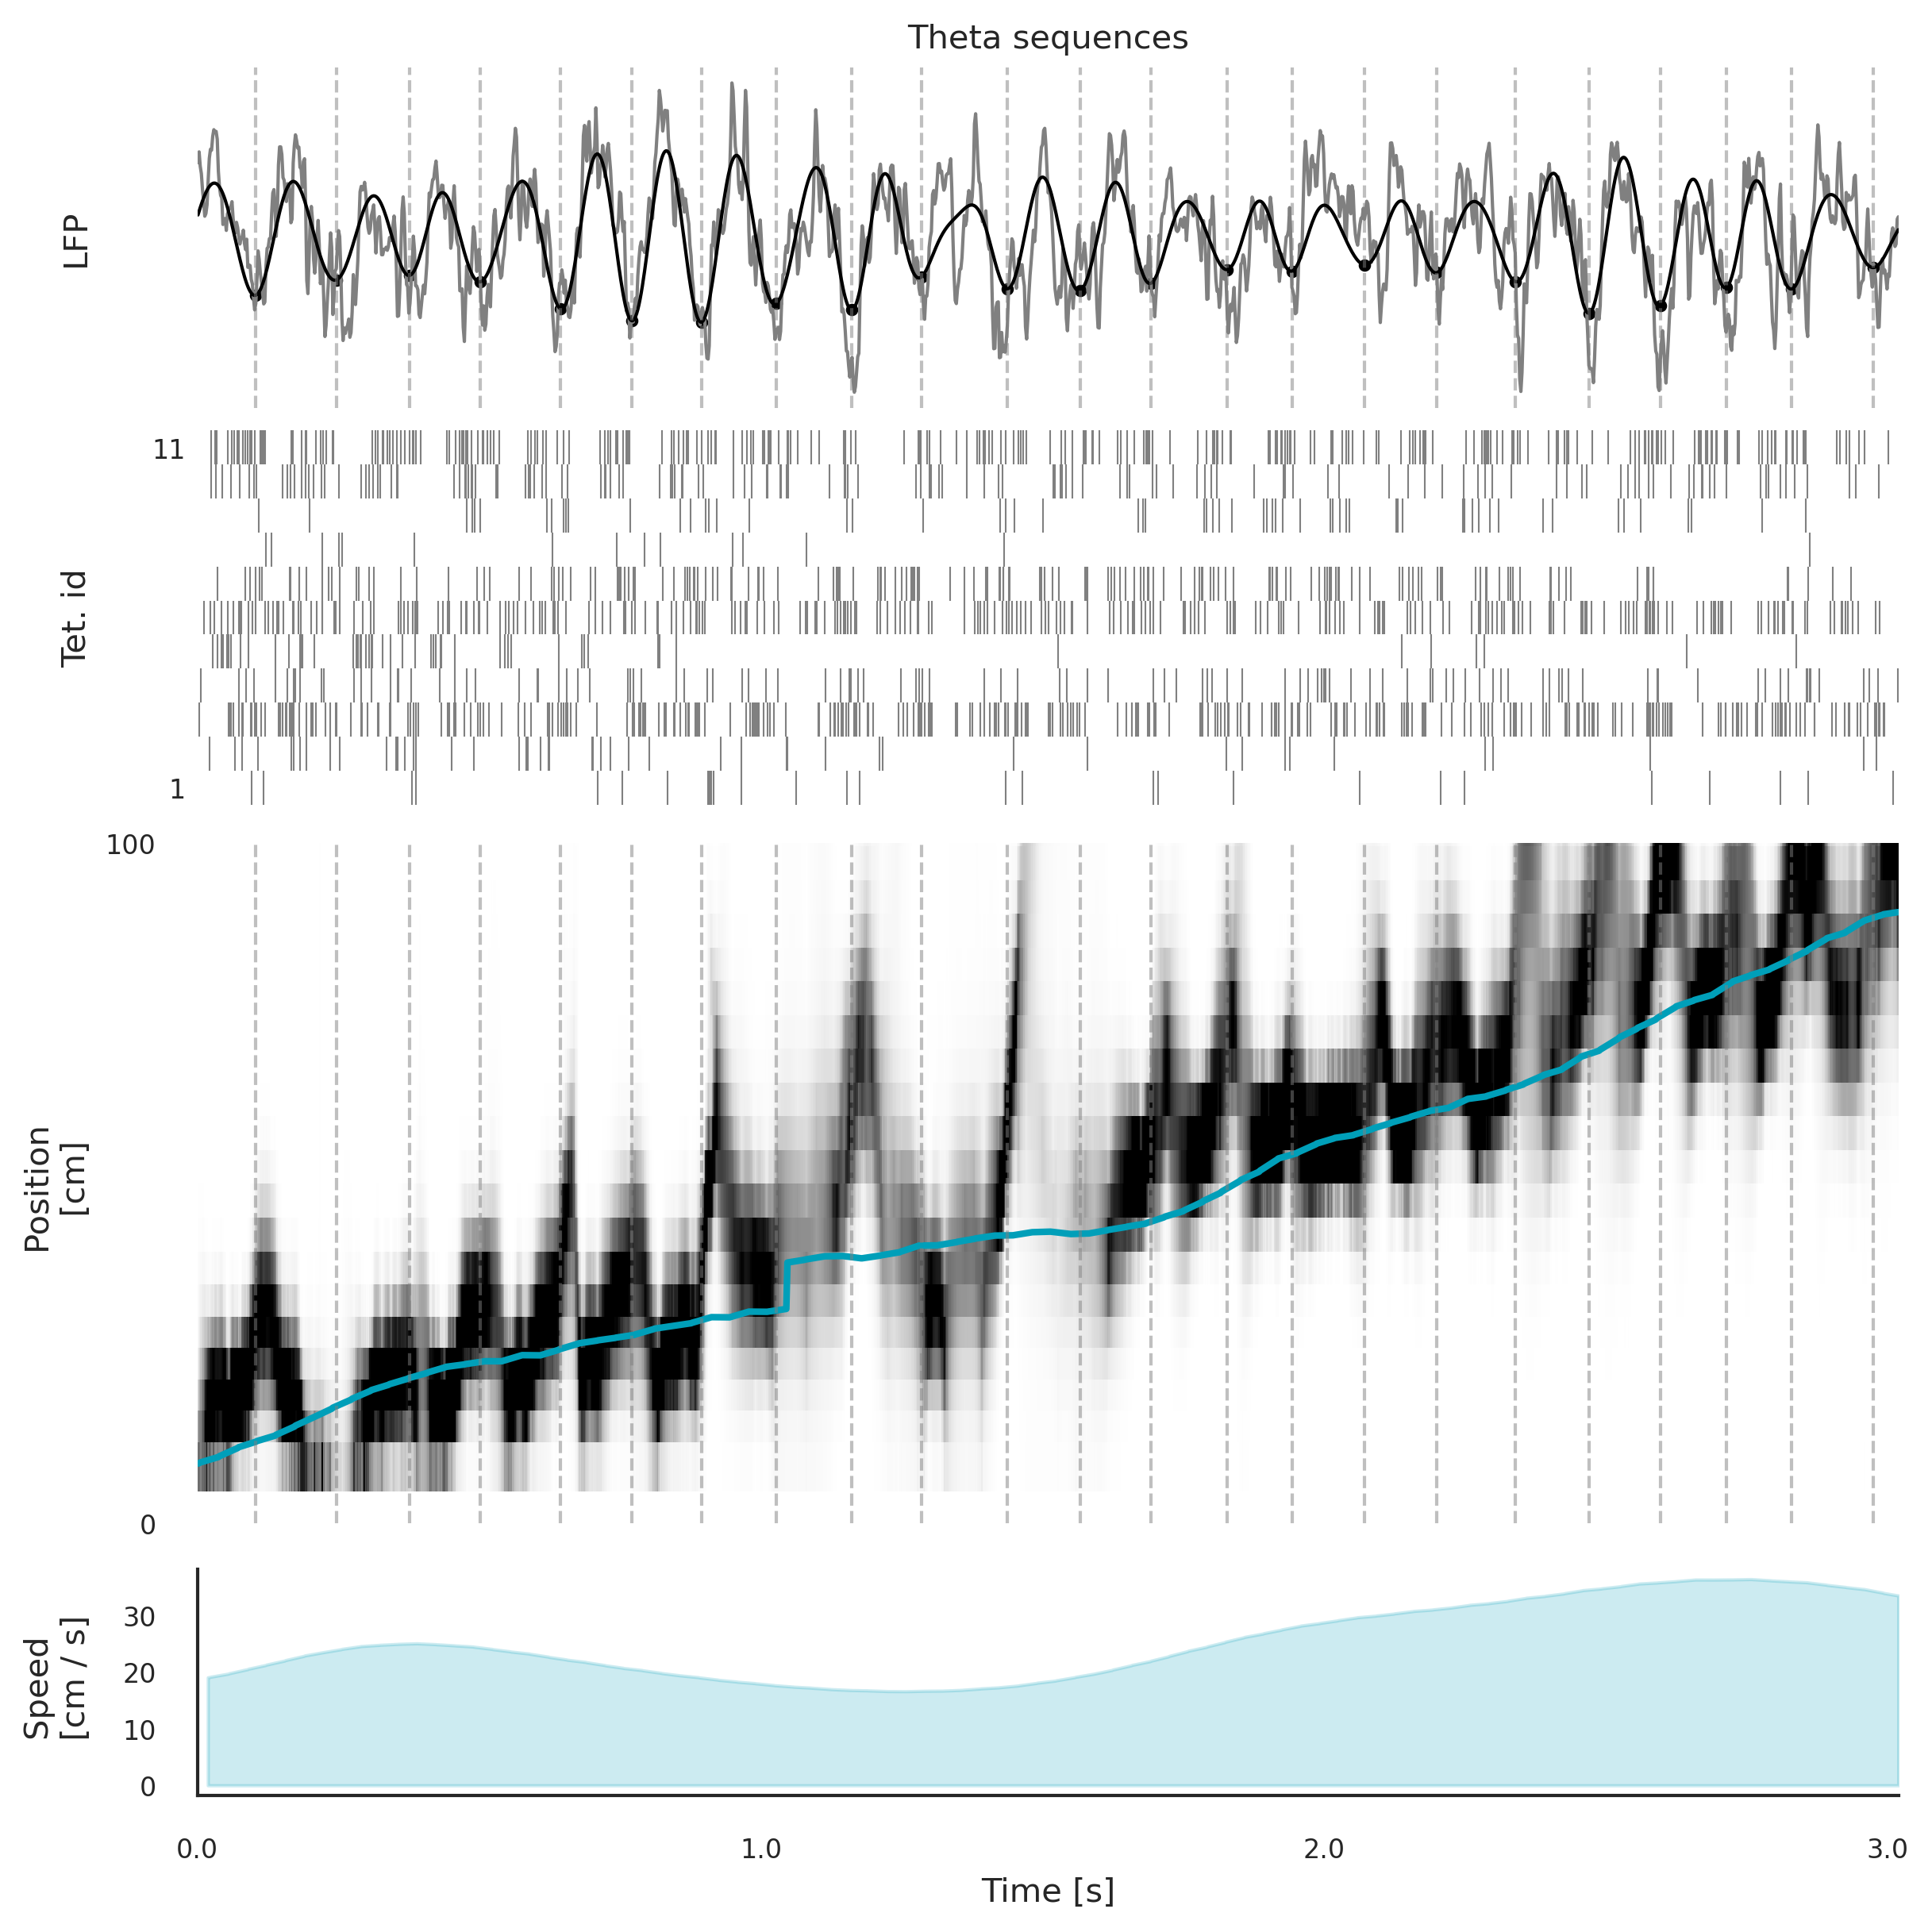

In [4]:
cmap = plt.cm.Greys
cmap.set_bad("white", alpha=1.0)
labelsize = 10
ticksize = 8
# set background color to white
sns.set_style("white")

fig, axes = plt.subplots(
    4,
    1,
    figsize=(8, 8),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1.5, 1.5, 3, 1]},
    dpi=300,
)

# ax 0: lfp from CA3
ind = 0
lfp = (
    data["lfps"]
    .reset_index(drop=True)
    .set_index(data["lfps"].index / np.timedelta64(1, "s"))
)

# plot as curve, not fill
axes[0].plot(
    lfp.loc[time_slice].index.values,
    lfp.loc[time_slice].iloc[:, ind].values.squeeze(),
    color="grey",
    linewidth=1,
)
axes[0].set_ylabel("LFP")

# add band passs filter to lfp.iloc[:,0], using band between 5-11Hz
lfp0 = bandpassfilter(lfp.iloc[:, ind], lowcut=5, highcut=11, fs=500)
# group the lfp0 into dataframe with time index
lfp0 = pd.DataFrame(lfp0, index=lfp.index)

# calculate the zero phase index
zero_phase_index = get_zero_phase(lfp0[time_slice])

# plot the filtered lfp
axes[0].plot(
    lfp.loc[time_slice].index.values, lfp0[time_slice], color="black", linewidth=1
)

axes[0].scatter(
    lfp0[time_slice].index.values[zero_phase_index],
    lfp0[time_slice].values.squeeze()[zero_phase_index],
    color="black",
    s=5,
)

# ax 0 y ticks off
axes[0].set_yticks([])

# add title
axes[0].set_title("Theta sequences", fontsize=labelsize)

n_tetrodes = len(multiunit_times)

# eventplot with small dot
axes[1].eventplot(
    [multiunit.loc[time_slice].index for multiunit in multiunit_times],
    color="grey",
    clip_on=False,
    linewidths=0.5,
)

# #get the index in time_slice of spike when it is not zero
# spike_index = np.where(pc_spike[time_slice].values != 0)[0]
# # get the time of spike in time_slice
# spike_time = pc_spike[time_slice].index[spike_index]
# #ebentplot the spike time as the extra dimension in axes[1]
# axes[1].eventplot(
#     spike_time,
#     color="red",
#     clip_on=False,
#     linewidths=0.5,
# )


# remove y tick bars
axes[1].tick_params(axis="y", length=0)
axes[1].set_yticks((0, n_tetrodes-1))
axes[1].set_yticklabels([1, n_tetrodes])
axes[1].set_ylim((0, n_tetrodes-1))

axes[1].set_ylabel("Tet. id")
axes[1].set_xticks([])
sns.despine(ax=axes[1], offset=0)
axes[1].spines["bottom"].set_visible(False)

# ax 1
results["acausal_posterior"].sum("state", skipna=False).sel(time=time_slice).plot(
    x="time",
    y="position",
    robust=True,
    ax=axes[2],
    cmap=cmap,
    vmin=0.0,
    add_colorbar=False,
)

axes[2].set_ylabel("Position \n [cm]")

axes[2].plot(
    data["position_info"].reset_index().set_index(t).loc[time_slice].index,
    data["position_info"].reset_index().set_index(t).loc[time_slice].linear_position,
    color="#009FB9",
    linestyle="-",
    linewidth=2,
    alpha=1.0,
)

# add multiple vertical lines to indicate the zero phase
for i in zero_phase_index:
    axes[0].axvline(
        x=lfp0[time_slice].index.values[i],
        color="grey",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
    )

    axes[2].axvline(
        x=lfp0[time_slice].index.values[i],
        color="grey",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
    )

axes[2].set_xlabel("")
axes[2].set_ylim(80, 180)
axes[2].set_yticks([80, 180])
axes[2].set_yticklabels([0, 100])

# ax 5
axes[3].fill_between(
    data["position_info"].reset_index().set_index(t).loc[time_slice].index,
    data["position_info"]
    .reset_index()
    .set_index(t)
    .loc[time_slice]
    .speed.values.squeeze(),
    color="#009FB9",
    linewidth=1,
    alpha=0.2,
)
axes[3].set_ylabel("Speed \n [cm / s]")
axes[3].set_xlabel("Time [s]")

# add x ticks to the bottom plot only
start_time = time_slice.start
end_time = time_slice.stop
axes[3].set_xticks(np.round(np.linspace(start_time, end_time, 4), 1))
# set tick labels by subtracting the start time
axes[3].set_xticklabels(np.round(np.linspace(start_time, end_time, 4) - start_time, 1))

# algin the y labels of all subplots
fig.align_ylabels(axes[:])

# set the font size as 12 for all the subplots
for ax in axes:
    ax.tick_params(labelsize=ticksize)
    ax.xaxis.label.set_size(labelsize)
    ax.yaxis.label.set_size(labelsize)
    # set axes off bottom left top and right
    ax.spines["bottom"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# add back axes[2] bottom and left spines
axes[3].spines["bottom"].set_visible(True)
axes[3].spines["left"].set_visible(True)
axes[3].spines["left"].set_linewidth(1.0)
axes[3].spines["bottom"].set_linewidth(1.0)

## make an animation

Frame: 1 / 301
Frame: 2 / 301
Frame: 3 / 301
Frame: 4 / 301
Frame: 5 / 301
Frame: 6 / 301
Frame: 7 / 301
Frame: 8 / 301
Frame: 9 / 301
Frame: 10 / 301
Frame: 11 / 301
Frame: 12 / 301
Frame: 13 / 301
Frame: 14 / 301
Frame: 15 / 301
Frame: 16 / 301
Frame: 17 / 301
Frame: 18 / 301
Frame: 19 / 301
Frame: 20 / 301
Frame: 21 / 301
Frame: 22 / 301
Frame: 23 / 301
Frame: 24 / 301
Frame: 25 / 301
Frame: 26 / 301
Frame: 27 / 301
Frame: 28 / 301
Frame: 29 / 301
Frame: 30 / 301
Frame: 31 / 301
Frame: 32 / 301
Frame: 33 / 301
Frame: 34 / 301
Frame: 35 / 301
Frame: 36 / 301
Frame: 37 / 301
Frame: 38 / 301
Frame: 39 / 301
Frame: 40 / 301
Frame: 41 / 301
Frame: 42 / 301
Frame: 43 / 301
Frame: 44 / 301
Frame: 45 / 301
Frame: 46 / 301
Frame: 47 / 301
Frame: 48 / 301
Frame: 49 / 301
Frame: 50 / 301
Frame: 51 / 301
Frame: 52 / 301
Frame: 53 / 301
Frame: 54 / 301
Frame: 55 / 301
Frame: 56 / 301
Frame: 57 / 301
Frame: 58 / 301
Frame: 59 / 301
Frame: 60 / 301
Frame: 61 / 301
Frame: 62 / 301
Frame: 63 / 301
F

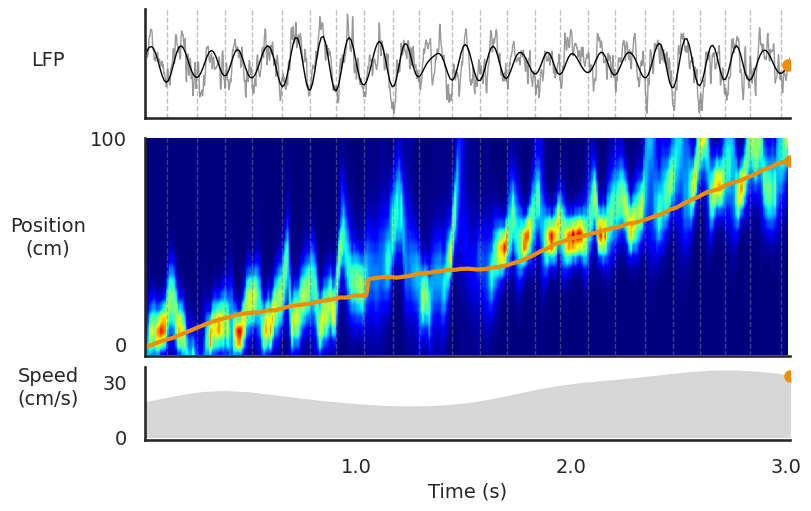

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns

# Set up style
cmap = plt.cm.jet
cmap.set_bad("white", alpha=1.0)
sns.set_style("white")

# Downsample data by a factor of 5
downsample_factor = 5
time_values = data["position_info"].reset_index().set_index(t).loc[time_slice].index[::downsample_factor]
position_values = data["position_info"].reset_index().set_index(t).loc[time_slice].linear_position[::downsample_factor]
speed_values = (data["position_info"].reset_index().set_index(t).loc[time_slice, "speed"][::downsample_factor])

# Set up figure
fig, axes = plt.subplots(
    3, 1, figsize=(8, 5), sharex=True, constrained_layout=True,
    gridspec_kw={"height_ratios": [1.5, 3, 1]}, dpi=100
)

# Plot Original LFP as Static Background (Grey)
ind = 0
lfp = (
    data["lfps"].reset_index(drop=True)
    .set_index(data["lfps"].index / np.timedelta64(1, "s"))
)
lfp0 = bandpassfilter(lfp.iloc[:, ind], lowcut=5, highcut=11, fs=500)
lfp0 = pd.DataFrame(lfp0, index=lfp.index)

lfp0_in_range = lfp0.loc[time_slice].iloc[::downsample_factor, :]

zero_phase_index = get_zero_phase(lfp0[time_slice])

# **Static Background: Raw LFP**
axes[0].plot(
    lfp.loc[time_slice].index.values,
    lfp.loc[time_slice].iloc[:, ind].values.squeeze(),
    color="grey", linewidth=1, alpha=0.8, label="Raw LFP"
)

# Plot phase lines
for i in zero_phase_index:
    axes[0].axvline(
        x=lfp0[time_slice].index.values[i],
        color="grey",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
    )
    axes[1].axvline(  # Static vertical lines in Axes 1
        x=lfp0[time_slice].index.values[i],
        color="grey",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
    )


axes[0].set_yticks([])

# Plot posterior probability
pos_bins = results["acausal_posterior"].sum("state", skipna=False).shape[1]
vmax = results["acausal_posterior"].sum("state", skipna=False).sel(time=time_values).max().values
vmin = results["acausal_posterior"].sum("state", skipna=False).sel(time=time_values).min().values
posmin = data["position_info"].reset_index().set_index(t).linear_position.min()
posmax = data["position_info"].reset_index().set_index(t).linear_position.max()
im = axes[1].imshow(
    np.zeros((pos_bins, len(time_values))),  # Empty matrix initially
    aspect="auto",
    cmap=cmap,
    extent=[time_values[0], time_values[-1], posmin, posmax],
    vmin=vmin,
    vmax=vmax,
    origin="lower"
)
(trajectory,) = axes[1].plot([], [], color="#F18D00", linestyle="-", linewidth=3, alpha=1.0)
axes[1].set_ylim(85, 180)
axes[1].set_yticks([90, 180])
axes[1].set_yticklabels([0, 100])

# Plot speed profile
speed_fill = axes[2].fill_between(
    time_values, speed_values, color="lightgrey", linewidth=1, alpha=0.9
)

axes[2].set_xticks(np.round(np.linspace(time_values[0], time_values[-1], 4), 1))
axes[2].set_xticklabels(np.round(np.linspace(time_values[0], time_values[-1], 4) - time_values[0], 1))
axes[2].set_yticks([0, 30])
# **Initialize Bandpass-Filtered LFP for Animation (Black)**
(filtered_lfp_line,) = axes[0].plot([], [], color="black", linewidth=1)
# Add the blue dot in all subplots
(dot_lfp,) = axes[0].plot([], [], color='#F18D00', marker="o", markersize=8)
(dot_position,) = axes[1].plot([], [], color='#F18D00', marker="o", markersize=8)
(dot_speed,) = axes[2].plot([], [], color='#F18D00', marker="o", markersize=8)

axes[2].set_xlabel("Time (s)", fontsize=14)
# Rotate y-labels to display horizontally
axes[0].set_ylabel("LFP", fontsize=14, labelpad=20, rotation=0)
axes[1].set_ylabel("Position\n(cm)", fontsize=14, rotation=0)
axes[2].set_ylabel("Speed\n(cm/s)", fontsize=14, rotation=0)

for ax in axes:
    sns.despine(ax=ax)
    #align ylabels vertically
    ax.yaxis.set_label_coords(-0.15, 0.45)  # Shift labels left (adjust as needed)
    #ticklabels fontsize as 12
    ax.tick_params(axis="both", labelsize=14)

# Animation update function
def update(frame):
    if frame == 0:
        return filtered_lfp_line, dot_lfp, dot_position, dot_speed, trajectory, im

    t = time_values[:frame]
    # print(t)
    print(f"Frame: {frame} / {len(time_values)}")

    t_last = float(t[-1])

    # Find the nearest available time index
    nearest_idx = lfp0.index.get_indexer([t_last], method="nearest")[0]
    
    nearest_time = lfp0.index[nearest_idx]
    # print(nearest_idx, nearest_time)
    # print(lfp0.index[:frame], lfp0.iloc[:frame, 0])
    
    # **Update Bandpass-Filtered LFP Line**
    filtered_lfp_line.set_data(
        lfp0_in_range.index.values[:frame],  # X-axis: Time (restricted to time_slice)
        lfp0_in_range.iloc[:frame, 0].values  # Y-axis: Filtered LFP values
    )

    dot_lfp.set_data([nearest_time], [lfp0.iloc[nearest_idx].values[0]])

    # Update posterior probability plot
    # **Fix the shape mismatch**
    posterior_snapshot = results["acausal_posterior"].sum("state", skipna=False).sel(time=t).values.T

    # ✅ Ensure posterior_snapshot is (59, 301) by pre-allocating
    fixed_snapshot = np.full((pos_bins, len(time_values)), np.nan)  # Pre-fill with NaN
    fixed_snapshot[:, :frame] = posterior_snapshot  # Fill only up to `frame`
    im.set_clim(vmin=vmin, vmax=vmax)  # Update color limits
    im.set_data(fixed_snapshot)  # ✅ Always sets (59, 301) shape

    # Update trajectory
    trajectory.set_data(time_values[:frame], position_values.values[:frame])

    # # Update dot_position
    dot_position.set_data([time_values[frame]], [position_values.values[frame]])
        
    # # update dot_speed
    dot_speed.set_data([time_values[frame]], [speed_values.values[frame]])

    return filtered_lfp_line, dot_lfp, dot_position, dot_speed, trajectory, im


# Slow down animation speed (1s of animation = 100ms of real-time)
playback_slowdown = 10

ani = animation.FuncAnimation(
    fig, update, frames=len(time_values), interval=2 * downsample_factor * playback_slowdown, blit=True
)

# Save or display animation
ani.save(
    "/home/zilong/Desktop/AdaptiveAttractorForSequences/PrezFigures/theta_sequences.gif",
    writer="ffmpeg",
    dpi=300,
)  # Saves as a video file


## make an animation with multiunit spikes 

Frame: 1 / 301
Frame: 2 / 301
Frame: 3 / 301
Frame: 4 / 301
Frame: 5 / 301
Frame: 6 / 301
Frame: 7 / 301
Frame: 8 / 301
Frame: 9 / 301
Frame: 10 / 301
Frame: 11 / 301
Frame: 12 / 301
Frame: 13 / 301
Frame: 14 / 301
Frame: 15 / 301
Frame: 16 / 301
Frame: 17 / 301
Frame: 18 / 301
Frame: 19 / 301
Frame: 20 / 301
Frame: 21 / 301
Frame: 22 / 301
Frame: 23 / 301
Frame: 24 / 301
Frame: 25 / 301
Frame: 26 / 301
Frame: 27 / 301
Frame: 28 / 301
Frame: 29 / 301
Frame: 30 / 301
Frame: 31 / 301
Frame: 32 / 301
Frame: 33 / 301
Frame: 34 / 301
Frame: 35 / 301
Frame: 36 / 301
Frame: 37 / 301
Frame: 38 / 301
Frame: 39 / 301
Frame: 40 / 301
Frame: 41 / 301
Frame: 42 / 301
Frame: 43 / 301
Frame: 44 / 301
Frame: 45 / 301
Frame: 46 / 301
Frame: 47 / 301
Frame: 48 / 301
Frame: 49 / 301
Frame: 50 / 301
Frame: 51 / 301
Frame: 52 / 301
Frame: 53 / 301
Frame: 54 / 301
Frame: 55 / 301
Frame: 56 / 301
Frame: 57 / 301
Frame: 58 / 301
Frame: 59 / 301
Frame: 60 / 301
Frame: 61 / 301
Frame: 62 / 301
Frame: 63 / 301
F

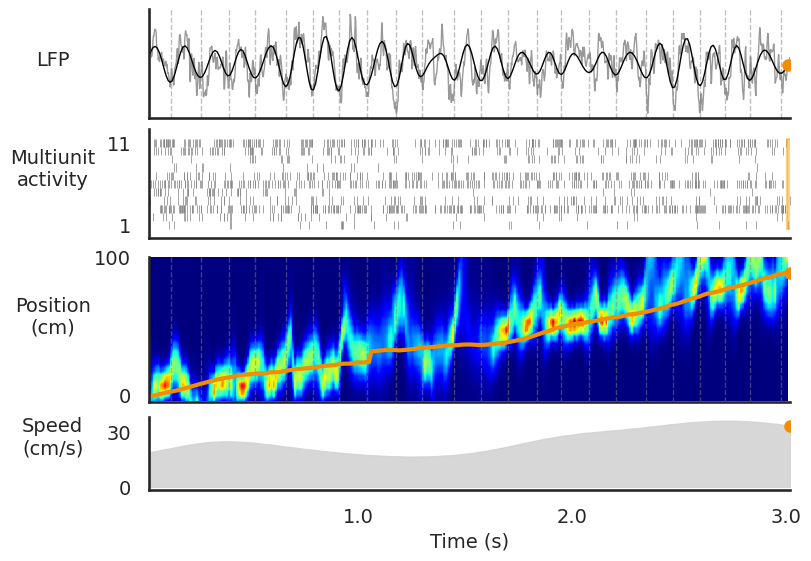

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import matplotlib.patches as patches

# Set up style
cmap = plt.cm.jet
cmap.set_bad("white", alpha=1.0)
sns.set_style("white")

# Downsample data by a factor of 5
downsample_factor = 5
time_values = data["position_info"].reset_index().set_index(t).loc[time_slice].index[::downsample_factor]
position_values = data["position_info"].reset_index().set_index(t).loc[time_slice].linear_position[::downsample_factor]
speed_values = data["position_info"].reset_index().set_index(t).loc[time_slice, "speed"][::downsample_factor]

# Set up figure
fig, axes = plt.subplots(
    4, 1, figsize=(8, 5.5), sharex=True, constrained_layout=True,
    gridspec_kw={"height_ratios": [1.5, 1.5, 2, 1]}, dpi=100
)

# Plot Original LFP as Static Background (Grey)
ind = 0
lfp = (
    data["lfps"].reset_index(drop=True)
    .set_index(data["lfps"].index / np.timedelta64(1, "s"))
)
lfp0 = bandpassfilter(lfp.iloc[:, ind], lowcut=5, highcut=11, fs=500)
lfp0 = pd.DataFrame(lfp0, index=lfp.index)

lfp0_in_range = lfp0.loc[time_slice].iloc[::downsample_factor, :]

zero_phase_index = get_zero_phase(lfp0[time_slice])

# **Static Background: Raw LFP**
axes[0].plot(
    lfp.loc[time_slice].index.values,
    lfp.loc[time_slice].iloc[:, ind].values.squeeze(),
    color="grey", linewidth=1, alpha=0.8, label="Raw LFP"
)

# **Plot phase lines**
for i in zero_phase_index:
    axes[0].axvline(x=lfp0[time_slice].index.values[i], color="grey", linestyle="--", linewidth=1, alpha=0.5)
    axes[2].axvline(x=lfp0[time_slice].index.values[i], color="grey", linestyle="--", linewidth=1, alpha=0.5)

axes[0].set_yticks([])

# **Plot static spike train**
n_tetrodes = len(multiunit_times)
axes[1].eventplot(
    [multiunit.loc[time_slice].index for multiunit in multiunit_times],
    color="grey",
    clip_on=False,
    linewidths=0.5,
)

axes[1].set_yticks([0, n_tetrodes-1])
axes[1].set_yticklabels([1, n_tetrodes])
axes[1].set_xticks([])
axes[1].spines["bottom"].set_visible(False)

# **Add orange moving time window (30 ms, centered at current time)**
time_window_ms = 0.03  # 30 ms
time_window_rect = patches.Rectangle(
    (time_values[0] - time_window_ms / 2, -0.5),  # Center at start
    time_window_ms,  # Width = 30 ms
    n_tetrodes,  # Height
    color="orange",
    alpha=0.5,  # Increased opacity
    zorder=2,
)
axes[1].add_patch(time_window_rect)

# **Plot posterior probability heatmap**
pos_bins = results["acausal_posterior"].sum("state", skipna=False).shape[1]
vmax = results["acausal_posterior"].sum("state", skipna=False).sel(time=time_values).max().values
vmin = results["acausal_posterior"].sum("state", skipna=False).sel(time=time_values).min().values
posmin = data["position_info"].reset_index().set_index(t).linear_position.min()
posmax = data["position_info"].reset_index().set_index(t).linear_position.max()
im = axes[2].imshow(
    np.zeros((pos_bins, len(time_values))),  # Empty matrix initially
    aspect="auto",
    cmap=cmap,
    extent=[time_values[0], time_values[-1], posmin, posmax],
    vmin=vmin,
    vmax=vmax,
    origin="lower"
)
(trajectory,) = axes[2].plot([], [], color="#F18D00", linestyle="-", linewidth=3, alpha=1.0)
axes[2].set_ylim(85, 180)
axes[2].set_yticks([90, 180])
axes[2].set_yticklabels([0, 100])

# **Plot speed profile**
speed_fill = axes[3].fill_between(
    time_values, speed_values, color="lightgrey", linewidth=1, alpha=0.9
)

axes[3].set_xticks(np.round(np.linspace(time_values[0], time_values[-1], 4), 1))
axes[3].set_xticklabels(np.round(np.linspace(time_values[0], time_values[-1], 4) - time_values[0], 1))
axes[3].set_yticks([0, 30])

# **Initialize Bandpass-Filtered LFP for Animation**
(filtered_lfp_line,) = axes[0].plot([], [], color="black", linewidth=1)
(dot_lfp,) = axes[0].plot([], [], color='#F18D00', marker="o", markersize=8)
(dot_position,) = axes[2].plot([], [], color='#F18D00', marker="o", markersize=8)
(dot_speed,) = axes[3].plot([], [], color='#F18D00', marker="o", markersize=8)

axes[3].set_xlabel("Time (s)", fontsize=14)
axes[0].set_ylabel("LFP", fontsize=14, labelpad=20, rotation=0)
axes[1].set_ylabel("Multiunit\nactivity", fontsize=14, rotation=0)
axes[2].set_ylabel("Position\n(cm)", fontsize=14, rotation=0)
axes[3].set_ylabel("Speed\n(cm/s)", fontsize=14, rotation=0)

for ax in axes:
    sns.despine(ax=ax)
    ax.yaxis.set_label_coords(-0.15, 0.45)  
    ax.tick_params(axis="both", labelsize=14)

# **Animation update function**
def update(frame):
    if frame == 0:
        return filtered_lfp_line, dot_lfp, dot_position, dot_speed, trajectory, im, time_window_rect

    t = time_values[:frame]
    print(f"Frame: {frame} / {len(time_values)}")

    t_last = float(t[-1])
    nearest_idx = lfp0.index.get_indexer([t_last], method="nearest")[0]
    nearest_time = lfp0.index[nearest_idx]

    # **Update Bandpass-Filtered LFP Line**
    filtered_lfp_line.set_data(lfp0_in_range.index.values[:frame], lfp0_in_range.iloc[:frame, 0].values)
    dot_lfp.set_data([nearest_time], [lfp0.iloc[nearest_idx].values[0]])

    # **Update Posterior Probability Heatmap**
    posterior_snapshot = results["acausal_posterior"].sum("state", skipna=False).sel(time=t).values.T
    fixed_snapshot = np.full((pos_bins, len(time_values)), np.nan)  
    fixed_snapshot[:, :frame] = posterior_snapshot  
    im.set_clim(vmin=vmin, vmax=vmax)  
    im.set_data(fixed_snapshot)  

    # **Update trajectory**
    trajectory.set_data(time_values[:frame], position_values.values[:frame])

    # **Update moving markers**
    dot_position.set_data([time_values[frame]], [position_values.values[frame]])
    dot_speed.set_data([time_values[frame]], [speed_values.values[frame]])

    # **Update time window position (centered)**
    time_window_rect.set_x(time_values[frame] - time_window_ms / 2)

    return filtered_lfp_line, dot_lfp, dot_position, dot_speed, trajectory, im, time_window_rect

# **Create animation**
ani = animation.FuncAnimation(
    fig, update, frames=len(time_values), interval=2 * downsample_factor * 10, blit=True
)

# **Save animation as MP4**
ani.save("/home/zilong/Desktop/AdaptiveAttractorForSequences/PrezFigures/theta_sequences.gif", writer="ffmpeg", dpi=300)

plt.show()


## try plot phase precession

In [60]:
pc_spike = data['spikes']['bon_08_04_017_001']
#convert to dataframe 
pc_spike = pd.DataFrame(pc_spike, index=pc_spike.index)
#reset index of serise to lfp0.index
pc_spike = pc_spike.reset_index(drop=True).set_index(lfp0.index)

phase = get_phase(lfp0.values.squeeze())
#convert phase to dataframe
phase_df = pd.DataFrame(phase, index=lfp0.index)

#reset index and set index to seconds
phase_df = phase_df.reset_index(drop=True).set_index(lfp0.index)

# #extract data from time_slice
# pc_spike = pc_spike.loc[time_slice]
# phase_df = phase_df.loc[time_slice]


positions = data["position_info"].reset_index().set_index(t).linear_position

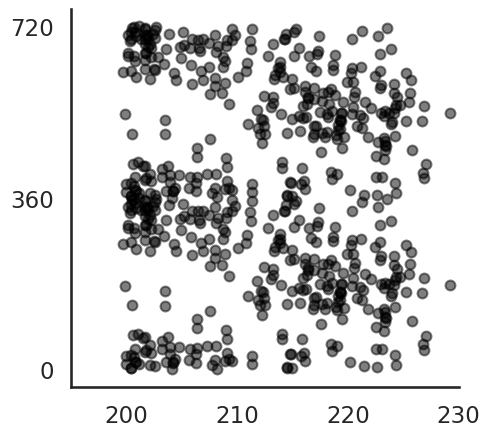

In [71]:
#plot spike phase against position when there is a spike

spike_phases = []
spike_pos = []

for i in range(len(pc_spike)):
    if pc_spike.iloc[i,0] > 0:
        spike_phases.append(phase_df.iloc[i,0])
        spike_pos.append(positions.iloc[i])

fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=100)

ax.scatter(spike_pos, spike_phases,color='black', s=50, alpha=0.5)
 # repeat the plot with a -2pi shift
ax.scatter(spike_pos, np.array(spike_phases)+ 2*np.pi, color='black', s=50, alpha=0.5)

ax.set_xlim(195, 230)
ax.set_yticks([0, 2*np.pi, 4*np.pi])
ax.set_yticklabels([0, 360, 720])
sns.despine()

